In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv("./titanic_toy.csv")
df.sample(5)

,Age,Fare,Family,Survived
813,6.0,31.2750,6,0
263,40.0,0.0000,0,0
513,54.0,NaN,1,1
435,14.0,120.0000,3,1
882,22.0,10.5167,0,0


In [4]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [5]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [6]:
X_train,X_test,y_train,_y_test = train_test_split(X,y,test_size=0.2,random_state=2)
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [7]:
X_train["Age_99"] = X_train["Age"].fillna(99)
X_train["Age_Minus1"] = X_train["Age"].fillna(-1)

X_train["Fare_999"] = X_train["Fare"].fillna(999)
X_train["Fare_Minus1"] = X_train["Fare"].fillna(-1)

In [9]:
X_train.sample(5)

,Age,Fare,Family,Age_99,Age_Minus1,Fare_999,Fare_Minus1
17,NaN,13.000,0,99.0,-1.0,13.000,13.000
760,NaN,14.500,0,99.0,-1.0,14.500,14.500
501,21.0,7.750,0,21.0,21.0,7.750,7.750
131,20.0,7.050,0,20.0,20.0,7.050,7.050
610,39.0,31.275,6,39.0,39.0,31.275,31.275


In [10]:
print('Original Age variance: ', X_train['Age'].var())
print('Age Variance after 99 imputation: ', X_train['Age_99'].var())
print('Age Variance after -1 imputation: ', X_train['Age_Minus1'].var())

print('Original Fare variance: ', X_train['Fare'].var())
print('Fare Variance after 999 imputation: ', X_train['Fare_999'].var())
print('Fare Variance after -1 imputation: ', X_train['Fare_Minus1'].var())

Original Age variance:  204.34951339046142
Age Variance after 99 imputation:  951.7275570187188
Age Variance after -1 imputation:  318.0896202624488
Original Fare variance:  2448.1979137063163
Fare Variance after 999 imputation:  47219.202652176304
Fare Variance after -1 imputation:  2378.5676784883494


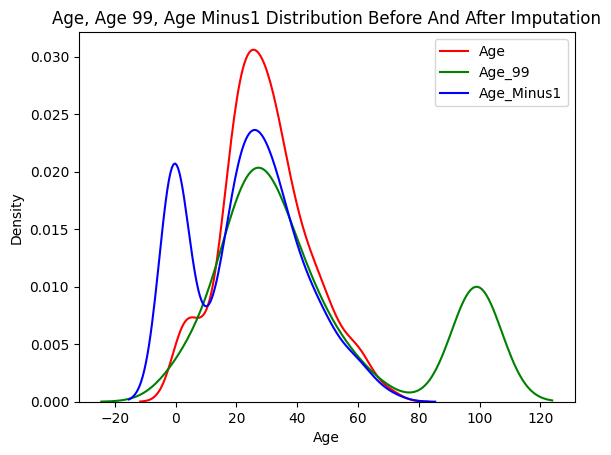

In [11]:
sns.kdeplot(X_train["Age"], color="red", label="Age")
sns.kdeplot(X_train["Age_99"], color="green", label="Age_99")
sns.kdeplot(X_train["Age_Minus1"], color="blue", label="Age_Minus1")

plt.title("Age, Age 99, Age Minus1 Distribution Before And After Imputation")
plt.legend()
plt.show()

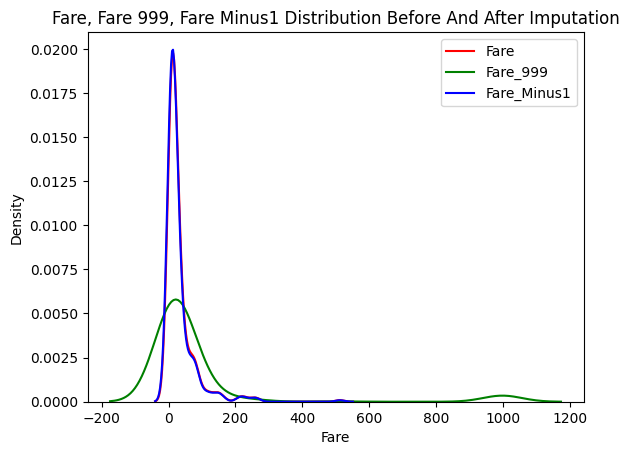

In [12]:
sns.kdeplot(X_train["Fare"], color="red", label="Fare")
sns.kdeplot(X_train["Fare_999"], color="green", label="Fare_999")
sns.kdeplot(X_train["Fare_Minus1"], color="blue", label="Fare_Minus1")

plt.title("Fare, Fare 999, Fare Minus1 Distribution Before And After Imputation")
plt.legend()
plt.show()

In [13]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_Minus1,Fare_999,Fare_Minus1
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
Age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
Age_Minus1,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
Fare_999,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
Fare_Minus1,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


In [14]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_Minus1,Fare_999,Fare_Minus1
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
Age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
Age_Minus1,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
Fare_999,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
Fare_Minus1,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000


Using Sklearn

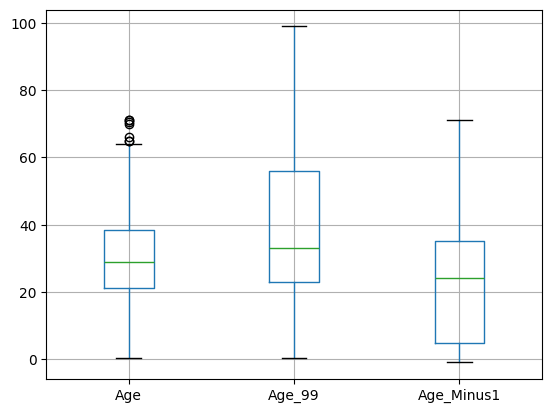

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [17]:
imputer1 = SimpleImputer(strategy='constant',fill_value=99)
imputer2 = SimpleImputer(strategy='constant',fill_value=999)

In [18]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [19]:
trf.fit(X_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [20]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [21]:
trf.named_transformers_['imputer2'].statistics_

array([999.])

In [22]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [23]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]], shape=(712, 3))